# Requirements

In [2]:
!pip install yfinance

In [3]:
!pip install pandas_datareader

In [4]:
import yfinance as yf
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [5]:
from IPython.display import display, HTML
import builtins
import sys

In [6]:
import pandas_datareader.data as pdr

In [7]:
def make_sequences(scaled_df, seq_length=20):
    X, y = [], []
    arr = scaled_df.values
    t_idx = feature_cols.index(target_col)
    for i in range(len(arr) - seq_length):
        X.append(arr[i:i+seq_length, :])
        y.append(arr[i+seq_length, t_idx])
    return torch.tensor(np.array(X), dtype=torch.float32), torch.tensor(np.array(y), dtype=torch.float32)

In [8]:
def mc_dropout_prediction(model, X, n_iter=100):
    model.train() # Mantener dropout activo para variar las predicciones
    preds = []
    with torch.no_grad():
        for _ in range(n_iter):
            pred = model(X.to(device)).squeeze().cpu().numpy()
            preds.append(pred)
    preds = np.array(preds)
    return preds.mean(axis=0), preds.std(axis=0)


# Enviroment

In [9]:
np.random.seed(1984)
torch.manual_seed(1984)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Data Upload

In [325]:
start="2024-01-01"
end="2026-03-27"

In [326]:
# A) Expedia Prices
Empresa="BE"
px = yf.download(Empresa, start=start, end=end, auto_adjust=False)
if isinstance(px.columns, pd.MultiIndex):
    px.columns = px.columns.get_level_values(0)

px = px.rename(columns={"Adj Close": "AdjClose"})
px = px[["Close", "AdjClose", "Volume"]].dropna()

[*********************100%***********************]  1 of 1 completed


In [327]:
pce_core = pdr.DataReader("PCEPILFE", "fred", start, end)  # Inflation
gdp = pdr.DataReader("GDP", "fred", start, end)           # GDP
ust10y = pdr.DataReader("DGS10", "fred", start, end)      # Bonds 10Y


In [328]:
pce_infl_yoy = pce_core.pct_change(12) * 100
pce_infl_yoy.columns = ["PCE_core_yoy"]

gdp_qoq_saar = ((1 + gdp.pct_change(1)) ** 4 - 1) * 100
gdp_qoq_saar.columns = ["GDP_qoq_saar"]

ust10y.columns = ["UST10Y"]

# Transformations

In [329]:
# Join Macroeconomics, gor each month in the quarter the macroeconomic data will be the data of the end of the period
idx = pd.date_range(start=px.index.min(), end=px.index.max(), freq="B")
df = pd.DataFrame(index=idx)
df = df.join(px[["Close", "Volume"]].reindex(idx).ffill())
df = df.join(pce_infl_yoy.reindex(idx).ffill())
df = df.join(gdp_qoq_saar.reindex(idx).ffill())
df = df.join(ust10y.reindex(idx).ffill()).dropna()

# Model Preparation

In [330]:
target_col = "Close"
feature_cols = ["Close", "Volume", "PCE_core_yoy", "GDP_qoq_saar", "UST10Y"]
data = df[feature_cols].copy()

In [331]:
# Test and Train sample
train_size = int(len(data) * 0.8)
train_df = data.iloc[:train_size]
test_df = data.iloc[train_size:]

In [332]:
# Normalization Min-Max
mins, maxs = train_df.min(), train_df.max()
ranges = (maxs - mins).replace(0, 1e-9)

In [333]:
train_scaled = (train_df - mins) / ranges
test_scaled = (test_df - mins) / ranges
t_min, t_max = mins[target_col], maxs[target_col]

In [334]:
X_train, y_train = make_sequences(train_scaled)
X_test, y_test = make_sequences(test_scaled)

# Model Definition

In [335]:
class EXPELSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim=32, num_layers=1, dropout=0.2):
        super(EXPELSTM, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :] # Tomamos solo el último estado de la secuencia
        out = self.dropout(out)
        return self.fc(out)

In [336]:
model = EXPELSTM(input_dim=len(feature_cols)).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

# Model Training

In [337]:
epochs = 2000
model.train()
for epoch in range(1, epochs + 1):
    optimizer.zero_grad()
    preds = model(X_train.to(device)).squeeze()
    loss = criterion(preds, y_train.to(device))
    loss.backward()
    optimizer.step()
    if epoch % 10 == 0:
        print(f"Epoch {epoch} - Loss: {loss.item():.6f}")

Epoch 10 - Loss: 0.114710
Epoch 20 - Loss: 0.080927
Epoch 30 - Loss: 0.073303
Epoch 40 - Loss: 0.058658
Epoch 50 - Loss: 0.037860
Epoch 60 - Loss: 0.018389
Epoch 70 - Loss: 0.010752
Epoch 80 - Loss: 0.007371
Epoch 90 - Loss: 0.009173
Epoch 100 - Loss: 0.008058
Epoch 110 - Loss: 0.007137
Epoch 120 - Loss: 0.008216
Epoch 130 - Loss: 0.008191
Epoch 140 - Loss: 0.007343
Epoch 150 - Loss: 0.007887
Epoch 160 - Loss: 0.006752
Epoch 170 - Loss: 0.006690
Epoch 180 - Loss: 0.007181
Epoch 190 - Loss: 0.007173
Epoch 200 - Loss: 0.005207
Epoch 210 - Loss: 0.006673
Epoch 220 - Loss: 0.005695
Epoch 230 - Loss: 0.005105
Epoch 240 - Loss: 0.004186
Epoch 250 - Loss: 0.005191
Epoch 260 - Loss: 0.004677
Epoch 270 - Loss: 0.005231
Epoch 280 - Loss: 0.005542
Epoch 290 - Loss: 0.004380
Epoch 300 - Loss: 0.005391
Epoch 310 - Loss: 0.004248
Epoch 320 - Loss: 0.004936
Epoch 330 - Loss: 0.005304
Epoch 340 - Loss: 0.004329
Epoch 350 - Loss: 0.003707
Epoch 360 - Loss: 0.003408
Epoch 370 - Loss: 0.003527
Epoch 380 

# Uncertainty with MC-Drop Out

In [338]:
mean_preds_scaled, std_preds_scaled = mc_dropout_prediction(model, X_test)

In [339]:
# USD Scaling 
mean_preds_usd = mean_preds_scaled * (t_max - t_min) + t_min
upper_bound = (mean_preds_scaled + 1.96 * std_preds_scaled) * (t_max - t_min) + t_min
lower_bound = (mean_preds_scaled - 1.96 * std_preds_scaled) * (t_max - t_min) + t_min
y_test_usd = y_test.numpy() * (t_max - t_min) + t_min

# Visualization

In [340]:
# 1. Obtenemos la longitud real de tus predicciones
n_predicciones = len(y_test_usd)

# 2. Ajustamos el índice tomando los ÚLTIMOS 'n' elementos del dataframe original
# Esto garantiza que si tienes 354 precios, tengas las últimas 354 fechas.
test_index_ajustado = test_df.index[-n_predicciones:]

# 3. Verificamos en consola (esto es para tu tranquilidad)
print(f"Longitud del índice: {len(test_index_ajustado)}")
print(f"Longitud de los precios: {len(y_test_usd)}")




Longitud del índice: 45
Longitud de los precios: 45


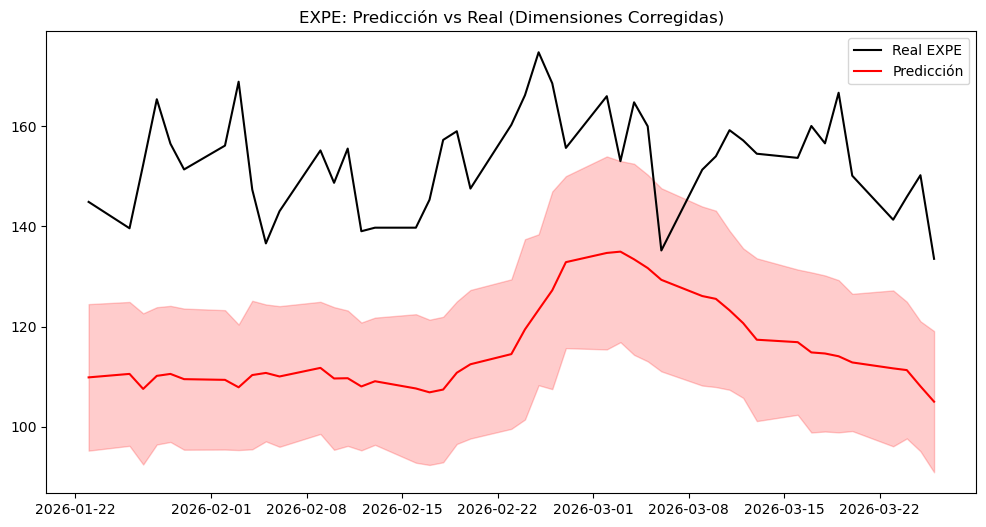

In [341]:
plt.figure(figsize=(12, 6))
plt.plot(test_index_ajustado, y_test_usd, label="Real EXPE", color="black")
plt.plot(test_index_ajustado, mean_preds_usd, label="Predicción", color="red")
plt.fill_between(test_index_ajustado, lower_bound, upper_bound, color="red", alpha=0.2)
plt.title("EXPE: Predicción vs Real (Dimensiones Corregidas)")
plt.legend()
plt.show()

In [342]:
import os
# Rango solicitado
fecha_inicio = "2026-03-30"
fecha_fin = "2026-04-04"

# Como EXPE cotiza en días hábiles, generamos solo días bursátiles
future_dates = pd.date_range(start=fecha_inicio, end=fecha_fin, freq="B")

# Longitud de secuencia usada en tu modelo
seq_length = 20

# Última ventana observada
rolling_window = data[feature_cols].iloc[-seq_length:].copy()

# Últimos valores conocidos de variables exógenas
last_volume = data["Volume"].iloc[-1]
last_pce = data["PCE_core_yoy"].iloc[-1]
last_gdp = data["GDP_qoq_saar"].iloc[-1]
last_ust10y = data["UST10Y"].iloc[-1]

future_preds = []

model.eval()

for fecha in future_dates:
    # Escalamos la ventana móvil con los mismos parámetros de entrenamiento
    rolling_scaled = (rolling_window[feature_cols] - mins[feature_cols]) / ranges[feature_cols]

    # Tensor para el modelo: (1, seq_length, n_features)
    X_future = torch.tensor(
        rolling_scaled.values[np.newaxis, :, :],
        dtype=torch.float32
    ).to(device)

    with torch.no_grad():
        pred_scaled = model(X_future).item()

    # Regresar a escala original
    pred_close = pred_scaled * (t_max - t_min) + t_min
    future_preds.append(pred_close)

    # Nueva fila proyectada
    nueva_fila = pd.DataFrame({
        "Close": [pred_close],
        "Volume": [last_volume],
        "PCE_core_yoy": [last_pce],
        "GDP_qoq_saar": [last_gdp],
        "UST10Y": [last_ust10y]
    }, index=[fecha])

    # Actualizamos la ventana
    rolling_window = pd.concat([rolling_window.iloc[1:], nueva_fila])

# DataFrame final
predicciones_futuras = pd.DataFrame({
    "Fecha": future_dates,
    f"{Empresa}_Prediccion": np.round(future_preds, 4)
})


# Ruta de salida
carpeta_salida = r"C:\Users\molvr\OneDrive\Desktop\proyecto_millonario"
os.makedirs(carpeta_salida, exist_ok=True)

archivo_excel = os.path.join(carpeta_salida, f"{Empresa}_prediccion.xlsx")
# Exportar a Excel
predicciones_futuras.to_excel(archivo_excel, index=False)

print("Archivo guardado en:")
print(archivo_excel)
display(predicciones_futuras)

Archivo guardado en:
C:\Users\molvr\OneDrive\Desktop\proyecto_millonario\BE_prediccion.xlsx


,Fecha,BE_Prediccion
0,2026-03-30,103.7652
1,2026-03-31,98.6363
2,2026-04-01,93.5867
3,2026-04-02,88.9621
4,2026-04-03,84.5770
